# Cross Team Model Comparison
This notebook loads all saved ML and DL models along with their respective vectorizers/tokenizers and evaluates them on the project test dataset ().


In [1]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

X_test = pd.read_csv('../data/processed/test.csv')['content'].astype(str)
y_test = pd.read_csv('../data/processed/test.csv')['label'].astype(int)


I0000 00:00:1786855391.413841   10144 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786855393.899869   10144 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786855419.865729   10144 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
results = []


def evaluate_and_plot(name, category, y_true, y_pred):
    print(f'{name} ({category})')
    print(classification_report(y_true, y_pred, target_names=['Fake', 'Real']))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Fake', 'Real'])
    ax.set_yticklabels(['Fake', 'Real'])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

    plt.tight_layout()
    plt.show()

    metrics = {
        'Model': name,
        'Category': category,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
    }
    results.append(metrics)
    return metrics


## Logistic Regression

Logistic Regression (ML)
              precision    recall  f1-score   support

        Fake       0.98      0.97      0.98      1790
        Real       0.98      0.99      0.98      2093

    accuracy                           0.98      3883
   macro avg       0.98      0.98      0.98      3883
weighted avg       0.98      0.98      0.98      3883



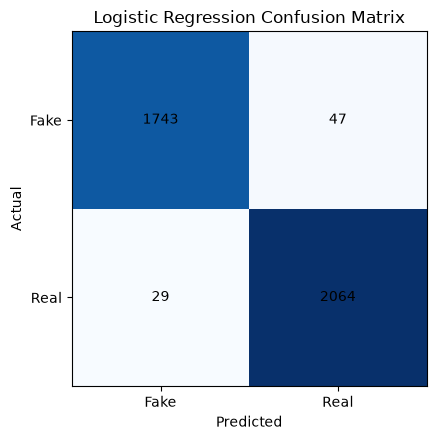

{'Model': 'Logistic Regression',
 'Category': 'ML',
 'Accuracy': 0.9804275045068246,
 'Precision': 0.9777356702984368,
 'Recall': 0.9861442904921166,
 'F1 Score': 0.9819219790675547}

In [ ]:
logreg_model = joblib.load('../models/LogReg/logreg_model.pkl')
logreg_tfidf = joblib.load('../models/LogReg/tfidf_vectorizer.pkl')
logreg_pred = logreg_model.predict(logreg_tfidf.transform(X_test))

logreg_metrics = evaluate_and_plot('Logistic Regression', 'ML', y_test, logreg_pred)
logreg_metrics


## Support Vector Machine

SVM (ML)
              precision    recall  f1-score   support

        Fake       0.90      0.99      0.94      1790
        Real       0.99      0.90      0.95      2093

    accuracy                           0.94      3883
   macro avg       0.95      0.95      0.94      3883
weighted avg       0.95      0.94      0.94      3883



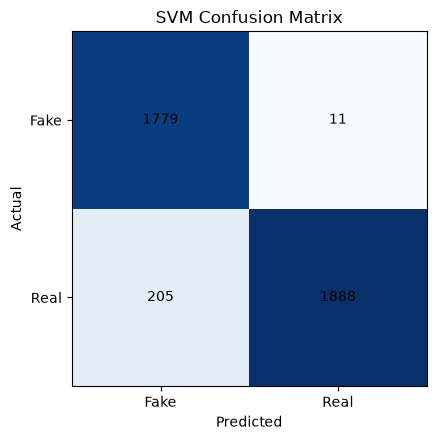

{'Model': 'SVM',
 'Category': 'ML',
 'Accuracy': 0.9443729075457121,
 'Precision': 0.9942074776197999,
 'Recall': 0.9020544672718586,
 'F1 Score': 0.9458917835671342}

In [ ]:
svm_model = joblib.load('../models/SVM/svm_model.pkl')
svm_tfidf = joblib.load('../models/SVM/tfidf_vectorizer.pkl')
svm_pred = svm_model.predict(svm_tfidf.transform(X_test))

svm_metrics = evaluate_and_plot('SVM', 'ML', y_test, svm_pred)
svm_metrics


## Random Forest

Random Forest (ML)
              precision    recall  f1-score   support

        Fake       0.70      1.00      0.83      1790
        Real       1.00      0.64      0.78      2093

    accuracy                           0.81      3883
   macro avg       0.85      0.82      0.80      3883
weighted avg       0.86      0.81      0.80      3883



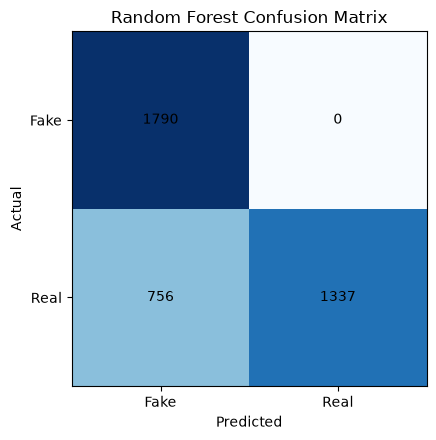

{'Model': 'Random Forest',
 'Category': 'ML',
 'Accuracy': 0.8053051764099923,
 'Precision': 1.0,
 'Recall': 0.6387959866220736,
 'F1 Score': 0.7795918367346939}

In [ ]:
rf_model = joblib.load('../models/RandomForest/random_forest_model.pkl')
rf_tfidf = joblib.load('../models/RandomForest/tfidf_vectorizer.pkl')
rf_pred = rf_model.predict(rf_tfidf.transform(X_test))

rf_metrics = evaluate_and_plot('Random Forest', 'ML', y_test, rf_pred)
rf_metrics


## CNN

E0000 00:00:1786855532.304289   10144 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1786855535.939074   15477 service.cc:153] XLA service 0x7f94c80312e0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786855535.939104   15477 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1786855536.040665   15477 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786855536.610579   15477 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


CNN (DL)
              precision    recall  f1-score   support

        Fake       0.98      0.99      0.99      1790
        Real       0.99      0.99      0.99      2093

    accuracy                           0.99      3883
   macro avg       0.99      0.99      0.99      3883
weighted avg       0.99      0.99      0.99      3883



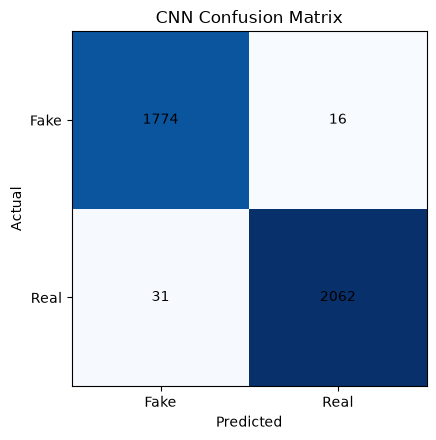

{'Model': 'CNN',
 'Category': 'DL',
 'Accuracy': 0.9878959567344836,
 'Precision': 0.9923002887391723,
 'Recall': 0.985188724319159,
 'F1 Score': 0.9887317190122272}

In [ ]:
cnn_model = load_model('../models/CNN/cnn_model.keras')
cnn_tokenizer = joblib.load('../models/CNN/cnn_tokenizer.pkl')
cnn_max_len = cnn_model.input_shape[1]

cnn_seq = cnn_tokenizer.texts_to_sequences(X_test)
cnn_pad = pad_sequences(cnn_seq, maxlen=cnn_max_len, padding='post', truncating='post')
cnn_prob = cnn_model.predict(cnn_pad, verbose=0).ravel()
cnn_pred = (cnn_prob > 0.5).astype(int)

cnn_metrics = evaluate_and_plot('CNN', 'DL', y_test, cnn_pred)
cnn_metrics


## GRU

GRU (DL)
              precision    recall  f1-score   support

        Fake       0.59      0.92      0.72      1790
        Real       0.87      0.46      0.60      2093

    accuracy                           0.67      3883
   macro avg       0.73      0.69      0.66      3883
weighted avg       0.74      0.67      0.66      3883



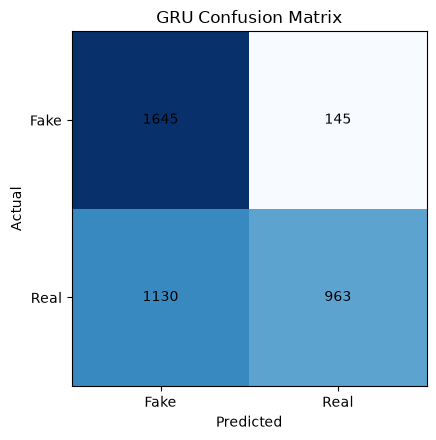

{'Model': 'GRU',
 'Category': 'DL',
 'Accuracy': 0.6716456348184393,
 'Precision': 0.8691335740072202,
 'Recall': 0.46010511227902534,
 'F1 Score': 0.6016869728209935}

In [ ]:
gru_model = load_model('../models/GRU/gru_model.keras')
gru_tokenizer = joblib.load('../models/GRU/gru_tokenizer.pkl')
gru_max_len = gru_model.input_shape[1]

gru_seq = gru_tokenizer.texts_to_sequences(X_test)
gru_pad = pad_sequences(gru_seq, maxlen=gru_max_len, padding='post', truncating='post')
gru_prob = gru_model.predict(gru_pad, verbose=0).ravel()
gru_pred = (gru_prob > 0.5).astype(int)

gru_metrics = evaluate_and_plot('GRU', 'DL', y_test, gru_pred)
gru_metrics


## LSTM

LSTM (DL)
              precision    recall  f1-score   support

        Fake       0.51      0.96      0.66      1790
        Real       0.86      0.19      0.32      2093

    accuracy                           0.55      3883
   macro avg       0.68      0.58      0.49      3883
weighted avg       0.70      0.55      0.48      3883



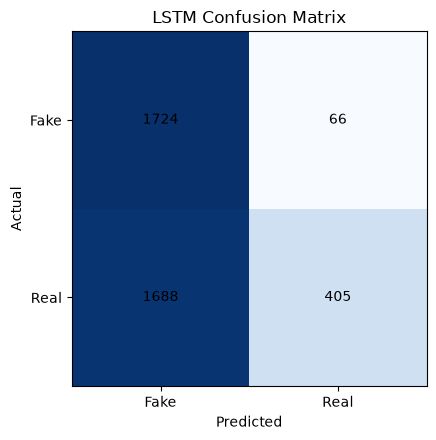

{'Model': 'LSTM',
 'Category': 'DL',
 'Accuracy': 0.5482874066443472,
 'Precision': 0.8598726114649682,
 'Recall': 0.19350215002388915,
 'F1 Score': 0.3159126365054602}

In [9]:
lstm_model = load_model('../models/LSTM/lstm_model.keras')
lstm_tokenizer = joblib.load('../models/LSTM/lstm_tokenizer.pkl')
lstm_max_len = joblib.load('../models/LSTM/lstm_max_length.pkl')

lstm_seq = lstm_tokenizer.texts_to_sequences(X_test)
lstm_pad = pad_sequences(lstm_seq, maxlen=lstm_max_len, padding='post', truncating='post')
lstm_prob = lstm_model.predict(lstm_pad, verbose=0).ravel()
lstm_pred = (lstm_prob > 0.5).astype(int)

lstm_metrics = evaluate_and_plot('LSTM', 'DL', y_test, lstm_pred)
lstm_metrics


## Final Comparison & Leaderboards

In [10]:
df_results = pd.DataFrame(results)

print("="*60)
print("MACHINE LEARNING MODELS LEADERBOARD")
print("="*60)
ml_leaderboard = df_results[df_results['Category'] == 'ML'].sort_values('F1 Score', ascending=False).reset_index(drop=True)
display(ml_leaderboard[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']])

print("" + "="*60)
print("DEEP LEARNING MODELS LEADERBOARD")
print("="*60)
dl_leaderboard = df_results[df_results['Category'] == 'DL'].sort_values('F1 Score', ascending=False).reset_index(drop=True)
display(dl_leaderboard[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']])

print("" + "="*60)
print("OVERALL COMBINED LEADERBOARD")
print("="*60)
overall_leaderboard = df_results.sort_values('F1 Score', ascending=False).reset_index(drop=True)
display(overall_leaderboard[['Model', 'Category', 'Accuracy', 'Precision', 'Recall', 'F1 Score']])


MACHINE LEARNING MODELS LEADERBOARD


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.980428,0.977736,0.986144,0.981922
1,SVM,0.944373,0.994207,0.902054,0.945892
2,Random Forest,0.805305,1.000000,0.638796,0.779592


DEEP LEARNING MODELS LEADERBOARD


,Model,Accuracy,Precision,Recall,F1 Score
0,CNN,0.987896,0.992300,0.985189,0.988732
1,GRU,0.671646,0.869134,0.460105,0.601687
2,LSTM,0.548287,0.859873,0.193502,0.315913


OVERALL COMBINED LEADERBOARD


,Model,Category,Accuracy,Precision,Recall,F1 Score
0,CNN,DL,0.987896,0.992300,0.985189,0.988732
1,Logistic Regression,ML,0.980428,0.977736,0.986144,0.981922
2,SVM,ML,0.944373,0.994207,0.902054,0.945892
3,Random Forest,ML,0.805305,1.000000,0.638796,0.779592
4,GRU,DL,0.671646,0.869134,0.460105,0.601687
5,LSTM,DL,0.548287,0.859873,0.193502,0.315913
